# Week 1 · Notebook 1 — The data, and your first tool

Welcome. Over three weeks you'll build a real algorithmic trading system: it reads
the market, forms strategies, tests them honestly, and — by week 3 — *learns* to
trade. Everything compounds; nothing you build gets thrown away.

Today is the gentlest day on purpose. Two goals:
1. Understand **the environment** — the world your strategies will live in.
2. Build your **first tool**: a price-charting function you'll reuse all week.

If your setup works and you draw a chart by the end, today succeeded.

## 1. The environment: what your strategies see

Every strategy in this program acts inside one shared world — a `DataFeed`. Think
of it as the market, frozen into a table you can query. It holds, for a whole
universe of stocks aligned to the same calendar:

- `feed.close` — closing prices, shape **(days × stocks)**
- `feed.returns` — daily returns (how much each stock moved), same shape
- `feed.volume` — how much traded

This is the single source of truth. Indicators read from it, strategies act on it,
the backtester walks through it day by day, and in week 3 the reinforcement-learning
agent will live inside it too. Learn its shape now and everything later is familiar.

In [1]:
import sys, os
while not os.path.isdir('src') and os.path.dirname(os.getcwd()) != os.getcwd():
    os.chdir('..')
sys.path.insert(0, 'src')
import numpy as np
import matplotlib.pyplot as plt

from tradinglab.data_feed import DataFeed

feed = DataFeed.from_dir('data/egx') # This function includes the data symbols
print('universe :', feed.symbols)
print('days     :', feed.n_days)
print('close is a table of shape (days, stocks):', feed.close.shape)
print()
print('last 5 closing prices of', feed.symbols[0], ':', feed.close[-5:, 0].round(2))
print('its last 5 daily returns             :', feed.returns[-5:, 0].round(4))

universe : ['ABUK', 'ADIB', 'ALCN', 'AMOC', 'ARCC', 'BTFH', 'CCAP', 'CIEB', 'COMI', 'DOMTY', 'EAST', 'EFID', 'EFIH', 'EGAL', 'EMFD', 'ETEL', 'FWRY', 'GBCO', 'HELI', 'HRHO', 'ISPH', 'JUFO', 'MCQE', 'MFPC', 'ORAS', 'ORWE', 'PHDC', 'RAYA', 'RMDA', 'SAUD', 'SKPC', 'SUGR', 'SWDY', 'TMGH']
days     : 1159
close is a table of shape (days, stocks): (1159, 34)

last 5 closing prices of ABUK : [70.88 71.45 71.52 71.32 73.  ]
its last 5 daily returns             : [-0.0196  0.008   0.001  -0.0028  0.0236]


## 2. Your first tool — `plot_price`

You'll look at prices constantly, so build a reusable chart function. Given the
figure is already set up for you, fill in the drawing: plot the closing price, then
plot each optional overlay (like a moving average) on top.

**In:** `dates`, `close`, and an optional `overlays` dict like `{'SMA20': array}`.
**Out:** the chart's `ax` (already returned for you).
**Hint:** `ax.plot(dates, close, label='close')`, then loop over `overlays.items()`.
**Done when:** the check counts the right number of lines.

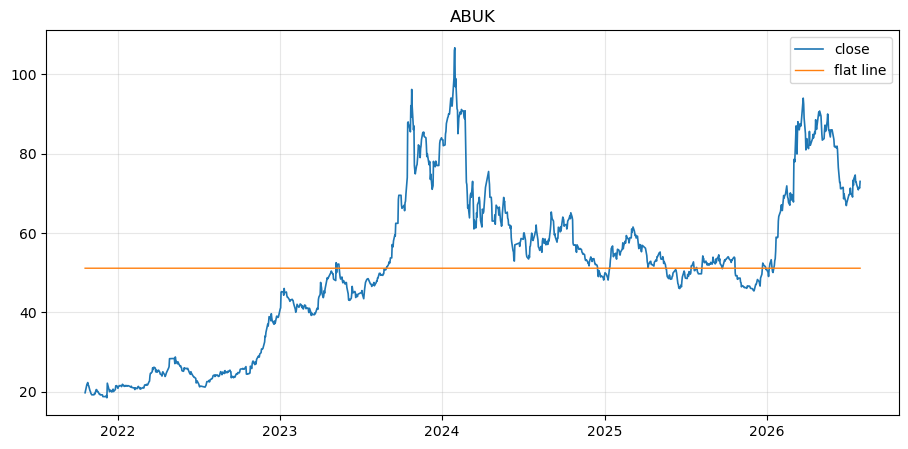

plot_price works ✓ — this is your chart tool for the whole week


In [2]:
def plot_price(dates, close, overlays=None, title='Price'):
    fig, ax = plt.subplots(figsize=(11, 5))
    ax.plot(dates, close, label='close', linewidth=1.2)
    for name, series in (overlays or {}).items():
        ax.plot(dates, series, label=name, linewidth=1.0)
    ax.set_title(title); ax.legend(); ax.grid(alpha=0.3)
    return ax


# el rakam 0 hwa el beye5tar el symbol placement el fel array - feh hena its using symbol feh position 0 (ABUK)
ax = plot_price(feed.dates, feed.close[:, 0],
                overlays={'flat line': np.full(feed.n_days, feed.close[:,0].mean())},
                title=feed.symbols[0])
assert len(ax.lines) == 2, 'expected close + 1 overlay'
plt.show()
print('plot_price works ✓ — this is your chart tool for the whole week')



# ax = plot_price(feed.dates, feed.close[:, 1],
#                 overlays={'flat line': np.full(feed.n_days, feed.close[:,1].mean())},
#                 title=feed.symbols[1])
# assert len(ax.lines) == 2, 'expected close + 1 overlay'
# plt.show()
# print('plot_price works ✓ — this is your chart tool for the whole week')


# ax = plot_price(feed.dates, feed.close[:, 2],
#                 overlays={'flat line': np.full(feed.n_days, feed.close[:,2].mean())},
#                 title=feed.symbols[2])
# assert len(ax.lines) == 2, 'expected close + 1 overlay'
# plt.show()
# print('plot_price works ✓ — this is your chart tool for the whole week')

C:\Users\alyka\AppData\Local\Temp\ipykernel_46608\214379996.py:249: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


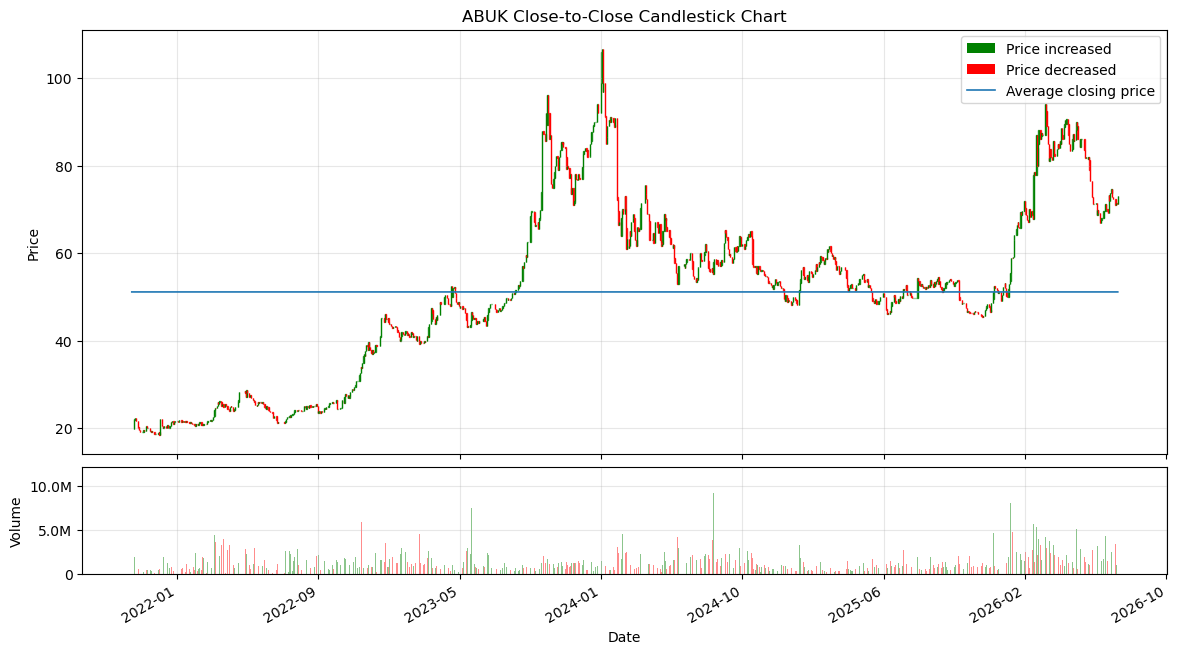

Candlestick and volume graph works ✓


In [3]:



import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from matplotlib.patches import Rectangle, Patch


def plot_candlestick_with_volume(
    dates,
    close_prices,
    volume,
    overlays=None,
    events=None,
    title='Close-to-Close Candlestick Chart'
):
    """
    Create approximate candlesticks using closing prices only,
    with a volume graph underneath.

    Open  = previous day's close
    Close = current day's close
    High  = maximum of open and close
    Low   = minimum of open and close

    Parameters
    ----------
    dates:
        Dates of the observations.

    close_prices:
        Closing prices for one stock.

    volume:
        Daily trading volume for the same stock.

    overlays:
        Optional dictionary of lines to plot over the price graph.

        Example:
        {
            'Average price': average_price_line
        }

    events:
        Optional list of corporate events.

        Example:
        [
            {'date': '2025-03-01', 'label': 'D'},
            {'date': '2025-05-15', 'label': 'E'}
        ]
    """

    # Convert data to NumPy arrays
    close_prices = np.asarray(close_prices, dtype=float)
    volume = np.asarray(volume, dtype=float)

    # Convert dates to datetime and then Matplotlib date numbers
    dates = pd.to_datetime(dates)
    date_numbers = mdates.date2num(dates)

    # Approximate each opening price using the previous closing price
    open_prices = np.concatenate(
        ([close_prices[0]], close_prices[:-1])
    )

    # Approximate high and low prices
    high_prices = np.maximum(open_prices, close_prices)
    low_prices = np.minimum(open_prices, close_prices)

    # Create two graphs sharing the same date axis
    fig, (ax_price, ax_volume) = plt.subplots(
        2,
        1,
        figsize=(14, 8),
        sharex=True,
        gridspec_kw={
            'height_ratios': [4, 1],
            'hspace': 0.05
        }
    )

    # Determine candle width
    if len(date_numbers) > 1:
        date_spacing = np.median(np.diff(date_numbers))
        candle_width = date_spacing * 0.65
    else:
        candle_width = 0.65

    # Store colours so the volume bars match the candles
    candle_colours = []

    # Draw each approximate candlestick
    for i in range(len(date_numbers)):
        date = date_numbers[i]

        open_price = open_prices[i]
        high_price = high_prices[i]
        low_price = low_prices[i]
        close_price = close_prices[i]

        # Green when today's close is greater than yesterday's close
        if close_price >= open_price:
            candle_colour = 'green'
        else:
            candle_colour = 'red'

        candle_colours.append(candle_colour)

        # Skip missing values
        if not np.all(
            np.isfinite(
                [open_price, high_price, low_price, close_price]
            )
        ):
            continue

        # Draw high-low wick
        ax_price.vlines(
            date,
            low_price,
            high_price,
            color=candle_colour,
            linewidth=0.8
        )

        # Calculate the candle body
        body_bottom = min(open_price, close_price)
        body_height = abs(close_price - open_price)

        # Make unchanged-price candles visible
        if body_height == 0:
            body_height = 0.001

        candle_body = Rectangle(
            (
                date - candle_width / 2,
                body_bottom
            ),
            candle_width,
            body_height,
            facecolor=candle_colour,
            edgecolor=candle_colour,
            alpha=0.8
        )

        ax_price.add_patch(candle_body)

    # Add optional overlay lines
    for name, series in (overlays or {}).items():
        ax_price.plot(
            date_numbers,
            series,
            label=name,
            linewidth=1.2
        )

    # Draw the volume bars
    ax_volume.bar(
        date_numbers,
        volume,
        width=candle_width,
        color=candle_colours,
        alpha=0.45
    )

    # Add optional event markers, such as D or E
    for event in events or []:
        event_date = mdates.date2num(
            pd.to_datetime(event['date'])
        )

        event_label = event['label']

        ax_volume.annotate(
            event_label,
            xy=(event_date, 0),
            xytext=(0, 8),
            textcoords='offset points',
            ha='center',
            va='bottom',
            fontsize=9,
            bbox={
                'boxstyle': 'circle,pad=0.25',
                'facecolor': 'white',
                'edgecolor': 'blue'
            }
        )

    # Create legend objects
    increase_patch = Patch(
        facecolor='green',
        label='Price increased'
    )

    decrease_patch = Patch(
        facecolor='red',
        label='Price decreased'
    )

    overlay_handles, overlay_labels = (
        ax_price.get_legend_handles_labels()
    )

    ax_price.legend(
        handles=[
            increase_patch,
            decrease_patch,
            *overlay_handles
        ]
    )

    # Format price graph
    ax_price.set_title(title)
    ax_price.set_ylabel('Price')
    ax_price.grid(alpha=0.3)

    # Format volume graph
    ax_volume.set_ylabel('Volume')
    ax_volume.set_xlabel('Date')
    ax_volume.grid(alpha=0.3)

    # Format large volume values such as 1,000,000 as 1.0M
    ax_volume.ticklabel_format(
        axis='y',
        style='plain'
    )

    ax_volume.yaxis.set_major_formatter(
        plt.FuncFormatter(
            lambda value, position:
                f'{value / 1_000_000:.1f}M'
                if abs(value) >= 1_000_000
                else (
                    f'{value / 1_000:.0f}K'
                    if abs(value) >= 1_000
                    else f'{value:.0f}'
                )
        )
    )

    # Format date labels
    ax_volume.xaxis.set_major_formatter(
        mdates.DateFormatter('%Y-%m')
    )

    fig.autofmt_xdate()
    fig.tight_layout()

    return ax_price, ax_volume


# Choose the stock position in the array
# Position 0 should be ABUK
symbol_position = 0

# Obtain closing prices and volume
close_prices = feed.close[:, symbol_position]
volume = feed.volume[:, symbol_position]

# Create a horizontal average-price line
average_close_line = np.full(
    feed.n_days,
    np.nanmean(close_prices)
)

# Create the graph
ax_price, ax_volume = plot_candlestick_with_volume(
    dates=feed.dates,
    close_prices=close_prices,
    volume=volume,
    overlays={
        'Average closing price': average_close_line
    },
    events=None,
    title=(
        f'{feed.symbols[symbol_position]} '
        f'Close-to-Close Candlestick Chart'
    )
)

plt.show()

print('Candlestick and volume graph works ✓')

## 3. What you can do this week

Now that you can see the data, here's the arc:
- **Notebook 2** — build the indicators (moving average, RSI) that turn prices into
  signals.
- **Notebook 3** — turn signals into a strategy, and write the one function at the
  heart of the whole engine.
- **Notebook 4** — backtest your strategy and **report** the result honestly against
  the benchmark.
- **Notebook 5** — put it all on a dashboard.

**Graduate** `plot_price` into `src/tradinglab/charting.py` (replace the stub), then:
`uv run pytest week1/tests/`. Tomorrow you build the indicators that go on this
chart.